In [5]:
import pandas as pd
# CSVファイルを読み込み、データフレームとして表示
df = pd.read_csv("../data/raw/dummy.csv", encoding="utf-8-sig")
df

,日付,内容,出金金額(円),入金金額(円),残高(円),メモ
0,2026/5/01,給料,NaN,250000.0,250000,-
1,2026/5/02,家賃,70000.0,NaN,180000,-
2,2026/5/03,スーパー,3500.0,NaN,176500,-
3,2026/5/04,コンビニ,650.0,NaN,175850,-
4,2026/5/05,電気代,8000.0,NaN,167850,-
5,2026/5/06,ガス代,4000.0,NaN,163850,-
6,2026/5/07,コンビニ,480.0,NaN,163370,-
7,2026/5/08,スーパー,4200.0,NaN,159170,-
8,2026/5/09,Amazonプライム,600.0,NaN,158570,-
9,2026/5/10,外食,2800.0,NaN,155770,-


In [7]:
import sqlite3
from pathlib import Path
# データベースに接続して、transactionsテーブルの内容を表示
conn = sqlite3.connect(Path("../data/processed/money.db"))
cursor = conn.execute("SELECT * FROM transactions")
print(cursor.fetchall())

[(1, '2026-05-01', 250000, '給料', 'dummy.csv', '収入'), (2, '2026-05-02', -70000, '家賃', 'dummy.csv', '住居費'), (3, '2026-05-03', -3500, 'スーパー', 'dummy.csv', '食費'), (4, '2026-05-04', -650, 'コンビニ', 'dummy.csv', '食費'), (5, '2026-05-05', -8000, '電気代', 'dummy.csv', '光熱費'), (6, '2026-05-06', -4000, 'ガス代', 'dummy.csv', '光熱費'), (7, '2026-05-07', -480, 'コンビニ', 'dummy.csv', '食費'), (8, '2026-05-08', -4200, 'スーパー', 'dummy.csv', '食費'), (9, '2026-05-09', -600, 'Amazonプライム', 'dummy.csv', '通信費'), (10, '2026-05-10', -2800, '外食', 'dummy.csv', '食費'), (11, '2026-05-11', -1500, '交通費', 'dummy.csv', '交通費'), (12, '2026-05-12', -3800, 'スーパー', 'dummy.csv', '食費'), (13, '2026-05-13', -320, 'コンビニ', 'dummy.csv', '食費'), (14, '2026-05-14', -20000, '奨学金返済', 'dummy.csv', '返済'), (15, '2026-05-15', -1800, '外食', 'dummy.csv', '食費'), (16, '2026-05-16', -2900, 'スーパー', 'dummy.csv', '食費'), (17, '2026-05-17', -2, '国税', 'dummy.csv', '税金'), (52, '2026-06-01', 250000, '給料', 'dummy2.csv', '収入'), (53, '2026-06-02', -70000, '家賃', 'dummy2.

In [8]:
from tracker.database import update_category, get_category_mapping
#カテゴリの更新
update_category(3, "食費")
update_category(9, "通信費")
update_category(2, "住居費")
update_category(4, "食費")
update_category(5, "光熱費")
update_category(6, "光熱費")
update_category(10, "食費")
update_category(11, "交通費")
update_category(14, "返済")
update_category(17, "税金")
update_category(1, "収入")

get_category_mapping()

{'給料': '収入',
 '家賃': '住居費',
 'スーパー': '食費',
 'コンビニ': '食費',
 '電気代': '光熱費',
 'ガス代': '光熱費',
 'Amazonプライム': '通信費',
 '外食': '食費',
 '交通費': '交通費',
 '奨学金返済': '返済',
 '国税': '税金'}

In [16]:
import sqlite3
from pathlib import Path

conn = sqlite3.connect(Path("../data/processed/money.db"))
cursor = conn.execute("SELECT id, description, category FROM transactions")
print(cursor.fetchall())

[(1, '給料', '収入'), (2, '家賃', '住居費'), (3, 'スーパー', '食費'), (4, 'コンビニ', '食費'), (5, '電気代', '光熱費'), (6, 'ガス代', '光熱費'), (7, 'コンビニ', '食費'), (8, 'スーパー', '食費'), (9, 'Amazonプライム', '通信費'), (10, '外食', '食費'), (11, '交通費', '交通費'), (12, 'スーパー', '食費'), (13, 'コンビニ', '食費'), (14, '奨学金返済', '返済'), (15, '外食', '食費'), (16, 'スーパー', '食費'), (17, '国税', '税金'), (52, '給料', '収入'), (53, '家賃', '住居費'), (54, 'スーパー', '食費'), (55, 'コンビニ', '食費'), (56, '電気代', '光熱費'), (57, '外食', '食費'), (58, 'Amazonプライム', '通信費'), (59, 'コンビニ', '食費'), (60, 'スーパー', '食費'), (61, '交通費', '交通費'), (62, '外食', '食費'), (63, 'スーパー', '食費'), (64, '奨学金返済', '返済'), (65, 'コンビニ', '食費'), (66, 'ガス代', '光熱費'), (67, '国税', '税金')]


In [2]:
from tracker.database import get_summary, get_category_summary

print(get_summary("2026-06-01", "2026-06-30"))
print(get_category_summary("2026-06-01", "2026-06-30"))

{'start_date': '2026-06-01', 'end_date': '2026-06-30', 'income': 250000, 'expense': -122653, 'balance': 127347}
[{'category': '住居費', 'total': -70000}, {'category': '返済', 'total': -20000}, {'category': '食費', 'total': -19550}, {'category': '光熱費', 'total': -11300}, {'category': '交通費', 'total': -1200}, {'category': '通信費', 'total': -600}, {'category': '税金', 'total': -3}]


In [4]:
!pip list


Package                   Version     Editable project location
------------------------- ----------- ------------------------------------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.5.20
cffi                      2.0.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
debugpy                   1.8.20
decorator                 5.3.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.16
ipykernel                 7.2.0
ipython         

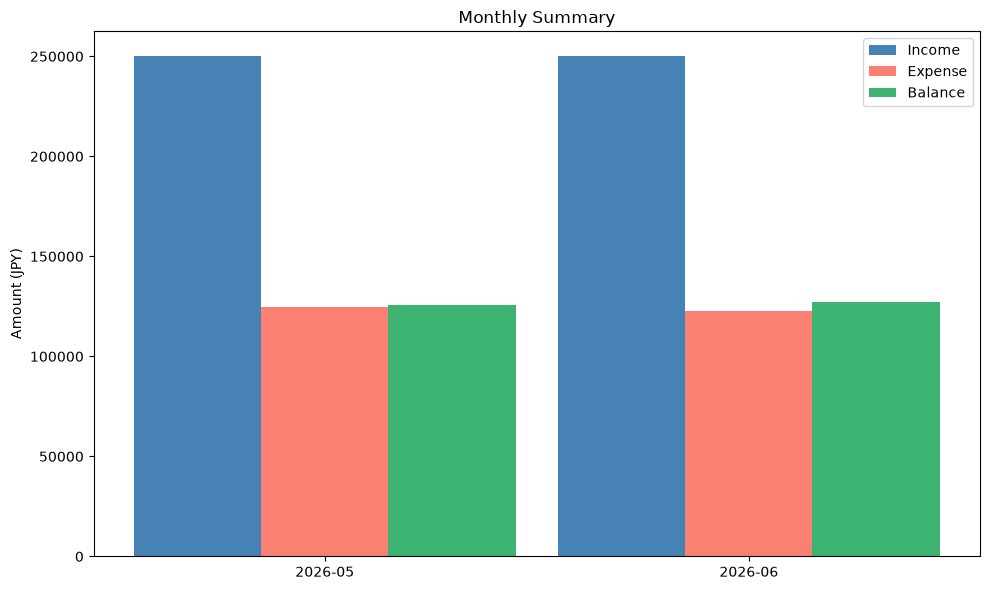

In [1]:
import matplotlib.pyplot as plt
import matplotlib
from tracker.database import get_summary

# 5月と6月のサマリーを取得
summaries = [
    get_summary("2026-05-01", "2026-05-31"),
    get_summary("2026-06-01", "2026-06-30"),
]

months = [s["start_date"][:7] for s in summaries]
incomes = [s["income"] for s in summaries]
expenses = [abs(s["expense"]) for s in summaries]
balances = [s["balance"] for s in summaries]

x = range(len(months))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width for i in x], incomes, width, label="Income", color="steelblue")
ax.bar(x, expenses, width, label="Expense", color="salmon")
ax.bar([i + width for i in x], balances, width, label="Balance", color="mediumseagreen")

ax.set_xticks(list(x))
ax.set_xticklabels(months)
ax.set_ylabel("Amount (JPY)")
ax.set_title("Monthly Summary")
ax.legend()
plt.tight_layout()
plt.show()

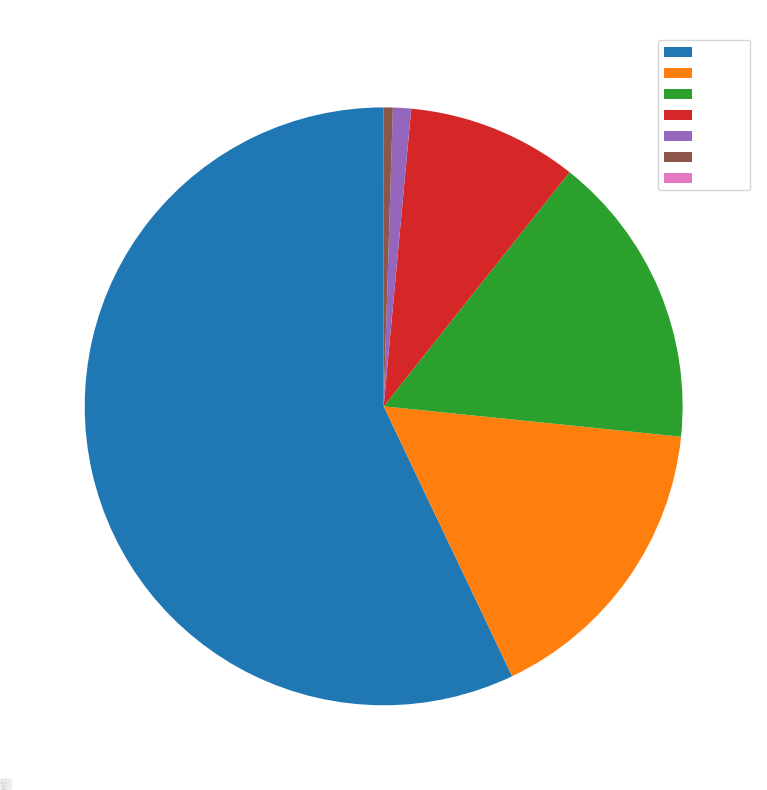

In [6]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'MS Gothic'

from tracker.database import get_category_summary

data = get_category_summary("2026-06-01", "2026-06-30")
labels = [d["category"] for d in data]
values = [abs(d["total"]) for d in data]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90, pctdistance=0.8)
ax.set_title("Category Summary (June 2026)")
ax.legend(labels, loc="best")

plt.tight_layout()
plt.show()